In [3]:
from pathlib import Path
import rasterio as rio
root = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/Images_small")
for p in sorted((root/"Before/S1GRD").glob("*.tif")) + sorted((root/"After/S1GRD").glob("*.tif")):
    with rio.open(p) as src:
        print(p.name, "bands=", src.count, "descriptions=", src.descriptions)


ASCENDING_before_s1_10_Nov_2023.tif bands= 3 descriptions= ('VV', 'VH', 'angle')
ASCENDING_after_s1_17_Nov_2023.tif bands= 3 descriptions= ('VV', 'VH', 'angle')


In [4]:
# /users/PGS0218/julina/.conda/envs/lora/bin/python3 - <<'PY'
from pathlib import Path
import rasterio as rio
import numpy as np

label_dir = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/Images_small/Relabeled")
for f in sorted(label_dir.glob("*.tif")):
    with rio.open(f) as src:
        y = src.read(1)
    vals, cnt = np.unique(y, return_counts=True)
    print(f"\n{f.name}")
    print("unique labels:", vals.tolist())
    print("counts:", dict(zip(vals.tolist(), cnt.tolist())))
# PY



c001_TerraMind_damage_11_16_Nov_2023_v2.tif
unique labels: [0, 1, 2, 3]
counts: {0: 81012, 1: 48179, 2: 7142, 3: 67946}


In [14]:
!"/users/PGS0218/julina/.conda/envs/lora/bin/python3" "../trainer.py" \
  hydra.mode=RUN \
  model.num_epochs=1 \
  train_loader.batch_size=2 \
  train_loader.num_augmentations=0 \
  model.num_classes=4 \
  model.modalities=[S2L2A] \
  '~train_loader.modalities.S1GRD' \
  '~validation_loader.modalities.S1GRD'


/users/PGS0218/julina/.conda/envs/lora/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
Error executing job with overrides: ['model.num_epochs=1', 'train_loader.batch_size=2', 'train_loader.num_augmentations=0', 'model.num_classes=4', 'model.modalities=[S2L2A]', '~train_loader.modalities.S1GRD', '~validation_loader.modalities.S1GRD']
Traceback (most recent call last):
  File "/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/damage_mapping/examples/../trainer.py", line 26, in main
    dir, subdir = hc['sweep']['dir'], hc['sweep']['subdir']
                                      ~~~~~~~~~~~^^^^^^^^^^
omegaconf.errors.InterpolationToMissingValueError: MissingMandatoryValue while resolving interpolation: Missing mandatory value: hydra.job.num
    full_key: hydra.sweep.subdir
    reference_type=SweepDir
    object_type=SweepDir

Set the environment variable HYDRA_FULL_ERROR=1 for a complete s

In [1]:
import rasterio as rio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

tif = "/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/multirun/Juls-test/test1/2026-03-09/14-05-21/0/geotiffs/predicted_map_0_colored.tif"
png = tif.replace(".tif", ".png")

with rio.open(tif) as src:
    arr = src.read(1)

cmap = ListedColormap(["black", "lime", "red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
plt.imsave(png, arr, cmap=cmap, vmin=0, vmax=2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..5756].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [122..7124].


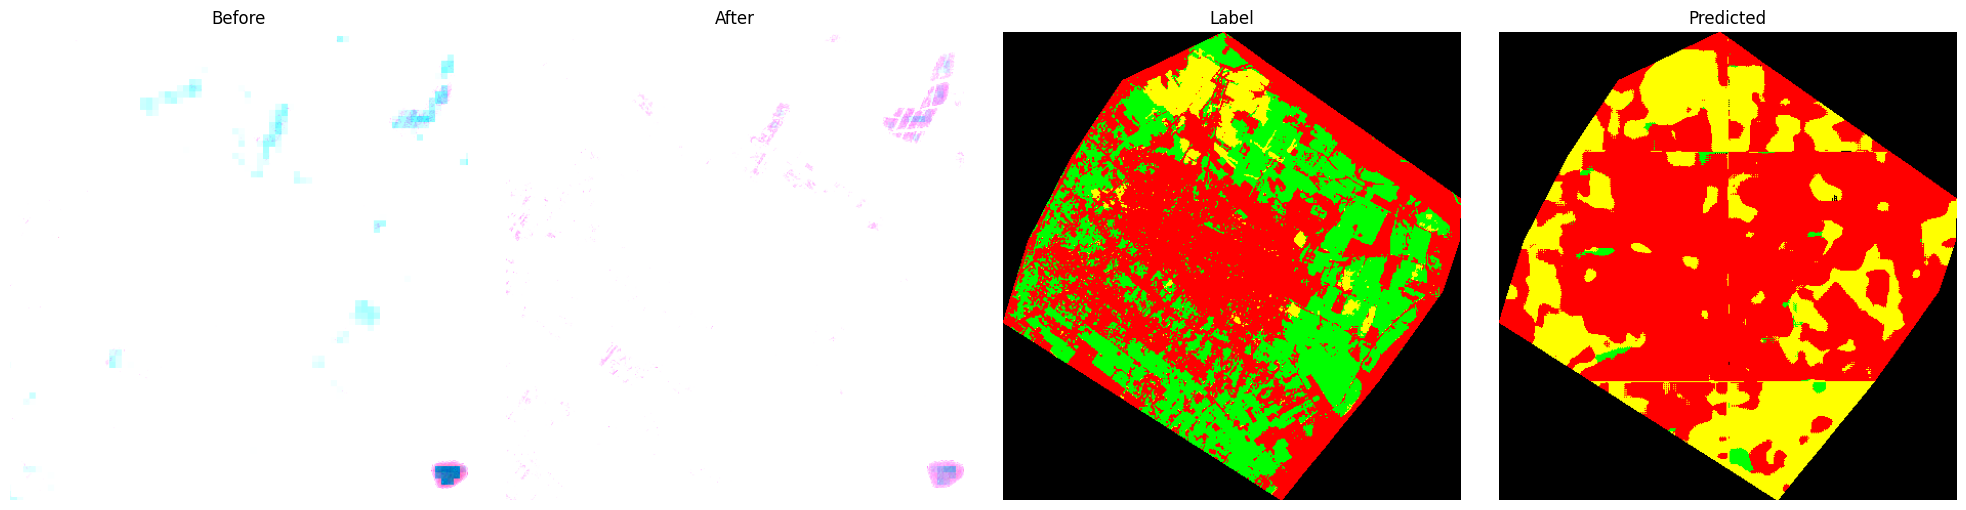

In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# File paths
before_path = "/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/Images_small/Before/S2L2A/c001_before_s2_11_Nov_2023.tif"
after_path = "/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/Images_small/After/S2L2A/c001_after_s2_16_Nov_2023.tif"
label_path = "/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/Images_small/Relabeled/c001_TerraMind_damage_11_16_Nov_2023_v2.tif"
pred_path = "/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-runs/terramind_train_2026-03-10_152519/geotiffs/predicted_map_0_colored.tif"

# Function to read tif as numpy array
def read_tif(path):
    with rasterio.open(path) as src:
        data = src.read()  # shape: (bands, H, W)
        # if multi-band, take first 3 bands for RGB visualization
        if data.shape[0] >= 3:
            img = np.stack([data[0], data[1], data[2]], axis=-1)
        else:
            img = data[0]  # single band
        return img

# Load images
before_img = read_tif(before_path)
after_img = read_tif(after_path)
label_img = read_tif(label_path)
pred_img = read_tif(pred_path)

# If predictions are class IDs, map to colors
def map_classes_to_colors(img, n_classes=4):
    colors = np.array([
        [0, 0, 0],        # class 0: black
        [0, 255, 0],      # class 1: green
        [255, 255, 0],    # class 2: yellow
        [255, 0, 0]       # class 3: red
    ])
    return colors[img.astype(int)]

# Map label and prediction to color images
label_color = map_classes_to_colors(label_img)
pred_color = map_classes_to_colors(pred_img)

# Plot all images side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(before_img)
axes[0].set_title("Before")
axes[1].imshow(after_img)
axes[1].set_title("After")
axes[2].imshow(label_color)
axes[2].set_title("Label")
axes[3].imshow(pred_color)
axes[3].set_title("Predicted")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()